Practical 11: Optimization Modeling and Simulation Modeling

 PART A - OPTIMIZATION MODELING

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Dataset
data = {
    "Product": ["A", "B"],
    "Profit": [40, 30],
    "Machine_Hours": [2, 1],
    "Labour_Hours": [1, 2]
}
products = pd.DataFrame(data)
print("PRODUCT DATASET")
print(products)


# Decision Variables
# x = Number of Product A
# y = Number of Product B

# Objective Function
# Maximize Profit = 40x + 30y

#  Machine Constraint
# 2x + y <= 100


# Labour Constraint
# x + 2y <= 80


# Non-negative constraints
# x >= 0
# y >= 0


# Solve Linear Programming Problem

# linprog performs minimization,
# so use negative profit for maximization

c = [-40, -30]

A = [
    [2, 1],   # Machine hours
    [1, 2]    # Labour hours
]

b = [100, 80]

bounds = [
    (0, None),
    (0, None)
]

result = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method="highs"
)


#  Optimal units

product_A = round(result.x[0])
product_B = round(result.x[1])


# Maximum profit

profit = (
    40 * product_A +
    30 * product_B
)


# Resource usage

machine_used = (
    2 * product_A +
    1 * product_B
)

labour_used = (
    1 * product_A +
    2 * product_B
)


# Display result

print("\nOPTIMAL SOLUTION")
print("---------------------------")

print("Product A Units:", product_A)
print("Product B Units:", product_B)

print("Machine Hours Used:", machine_used)
print("Machine Hours Available:", 100)

print("Labour Hours Used:", labour_used)
print("Labour Hours Available:", 80)

print("Maximum Profit:", profit)


# Result DataFrame

optimization_result = pd.DataFrame({
    "Measure": [
        "Product A Units",
        "Product B Units",
        "Machine Hours Used",
        "Labour Hours Used",
        "Maximum Profit"
    ],

    "Value": [
        product_A,
        product_B,
        machine_used,
        labour_used,
        profit
    ]
})

print("\nOPTIMIZATION RESULT")
print(optimization_result)

PRODUCT DATASET
  Product  Profit  Machine_Hours  Labour_Hours
0       A      40              2             1
1       B      30              1             2

OPTIMAL SOLUTION
---------------------------
Product A Units: 40
Product B Units: 20
Machine Hours Used: 100
Machine Hours Available: 100
Labour Hours Used: 80
Labour Hours Available: 80
Maximum Profit: 2200

OPTIMIZATION RESULT
              Measure  Value
0     Product A Units     40
1     Product B Units     20
2  Machine Hours Used    100
3   Labour Hours Used     80
4      Maximum Profit   2200


PART B - SIMULATION MODELING


30-DAY DEMAND DATASET
    Day  Daily Demand
0     1            26
1     2            39
2     3            48
3     4            34
4     5            30
5     6            27
6     7            48
7     8            40
8     9            26
9    10            45
10   11            38
11   12            42
12   13            30
13   14            30
14   15            43
15   16            40
16   17            23
17   18            27
18   19            43
19   20            22
20   21            41
21   22            40
22   23            21
23   24            43
24   25            31
25   26            49
26   27            25
27   28            21
28   29            47
29   30            40

SIMULATION - INVENTORY LEVEL 30
    Day  Demand  Inventory  Units Sold  Units Left  Shortage
0     1      26         30          26           4         0
1     2      39         30          30           0         9
2     3      48         30          30           0        18
3     4      34   

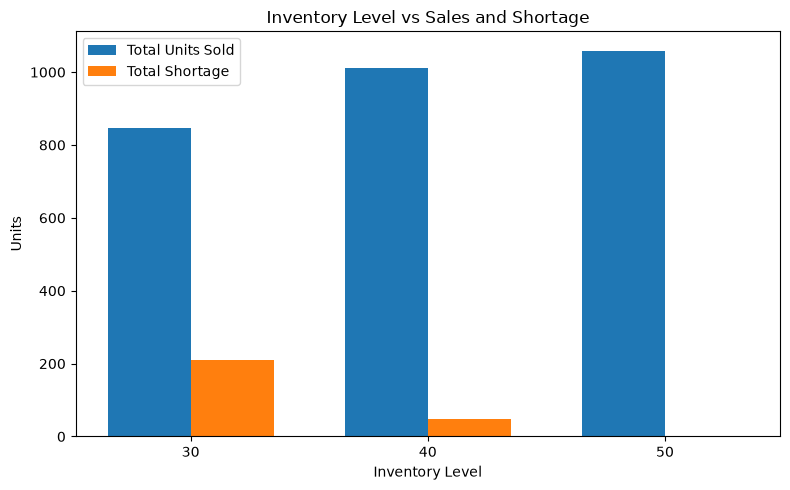


CONCLUSION
Increasing the inventory level increases the number of units that can be sold.
At the same time, increasing inventory reduces the shortage caused by high demand.
The simulation helps the supermarket compare different inventory levels before making an inventory decision.


In [5]:
#  Generate random demand for 30 days
np.random.seed(42)
demand = np.random.randint(
    20,
    51,
    size=30
)


# Create dataset
demand_data = pd.DataFrame({
    "Day": range(1, 31),
    "Daily Demand": demand
})

print("\n30-DAY DEMAND DATASET")
print(demand_data)


# Save dataset
demand_data.to_csv(
    "Supermarket_Daily_Demand.csv",
    index=False
)

# SIMULATION FUNCTION
def simulate_inventory(demand, inventory):

    # 18. Units sold
    units_sold = np.minimum(
        demand,
        inventory
    )

    # Units left
    units_left = np.maximum(
        inventory - demand,
        0
    )

    # Shortage
    shortage = np.maximum(
        demand - inventory,
        0
    )

    simulation = pd.DataFrame({

        "Day": range(1, 31),

        "Demand": demand,

        "Inventory": inventory,

        "Units Sold": units_sold,

        "Units Left": units_left,

        "Shortage": shortage
    })

    return simulation


# INVENTORY LEVEL = 30
simulation_30 = simulate_inventory(
    demand,
    30
)
print("\nSIMULATION - INVENTORY LEVEL 30")
print(simulation_30)

print(
    "\nTotal Units Sold:",
    simulation_30["Units Sold"].sum()
)
print(
    "Total Shortage:",
    simulation_30["Shortage"].sum()
)

# INVENTORY LEVELS = 30, 40, 50
inventory_levels = [30, 40, 50]
summary = []
for inventory in inventory_levels:

    simulation = simulate_inventory(
        demand,
        inventory
    )

    total_sales = simulation[
        "Units Sold"
    ].sum()

    total_shortage = simulation[
        "Shortage"
    ].sum()

    total_left = simulation[
        "Units Left"
    ].sum()

    summary.append({

        "Inventory Level": inventory,

        "Total Units Sold": total_sales,

        "Total Units Left": total_left,

        "Total Shortage": total_shortage
    })


#  Store results in DataFrame
summary_df = pd.DataFrame(summary)
print("\nSIMULATION SUMMARY")
print(summary_df)

# Save summary dataset

summary_df.to_csv(
    "Inventory_Simulation_Summary.csv",
    index=False
)

#  CREATE CHART
plt.figure(figsize=(8, 5))

x = np.arange(
    len(inventory_levels)
)
width = 0.35
plt.bar(
    x - width/2,
    summary_df["Total Units Sold"],
    width,
    label="Total Units Sold"
)
plt.bar(
    x + width/2,
    summary_df["Total Shortage"],
    width,
    label="Total Shortage"
)
plt.xlabel("Inventory Level")
plt.ylabel("Units")
plt.title(
    "Inventory Level vs Sales and Shortage"
)
plt.xticks(
    x,
    inventory_levels
)
plt.legend()
plt.tight_layout()
plt.show()

#  CONCLUSION
print("\nCONCLUSION")

print(
    "Increasing the inventory level increases the "
    "number of units that can be sold."
)

print(
    "At the same time, increasing inventory reduces "
    "the shortage caused by high demand."
)

print(
    "The simulation helps the supermarket compare "
    "different inventory levels before making an "
    "inventory decision."
)